In [89]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [90]:
def v(t,s,K,sigma,r,T):
    d1 = (np.log(s/K)+(r+0.5*sigma**2)*(T-t))/(sigma*np.sqrt(T-t))
    d2 = d1-sigma*np.sqrt(T-t)
    return s*stats.norm.cdf(d1)-np.exp(-r*(T-t))*K*stats.norm.cdf(d2),stats.norm.cdf(d1)

In [91]:
s0 = 100
T = 5
r = 0.03
sigma = 0.35
K = 130
N = 1000
n = 100
t = np.linspace(0,T,n+1)

In [92]:
W = np.zeros(shape=(n+1,N))
dt = T/n
for i in range(1,n+1):
    W[i,:] = W[i-1,:]+np.sqrt(dt)*np.random.normal(0,1,size=(N))

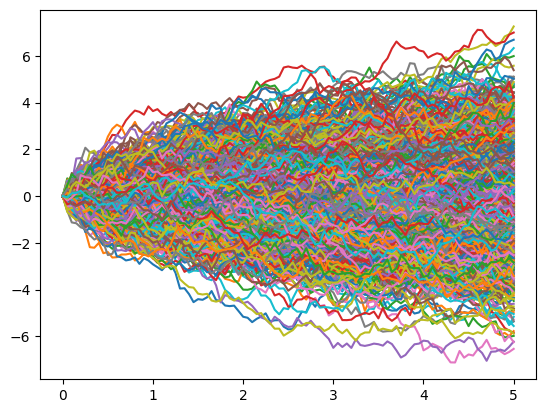

In [93]:
plt.plot(t,W)
plt.show()

In [94]:
S = s0*np.exp((r-0.5*sigma**2)*t[:, None]+sigma*W)

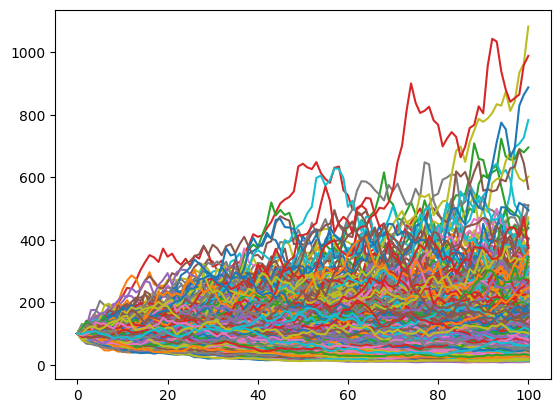

In [95]:
plt.plot(S)
plt.show()

In [96]:
val,eta1 = v(t[:, None],S,K,sigma,r,T)

C:\Users\trist\AppData\Local\Temp\ipykernel_17176\3959196561.py:2: RuntimeWarning: divide by zero encountered in divide
  d1 = (np.log(s/K)+(r+0.5*sigma**2)*(T-t))/(sigma*np.sqrt(T-t))


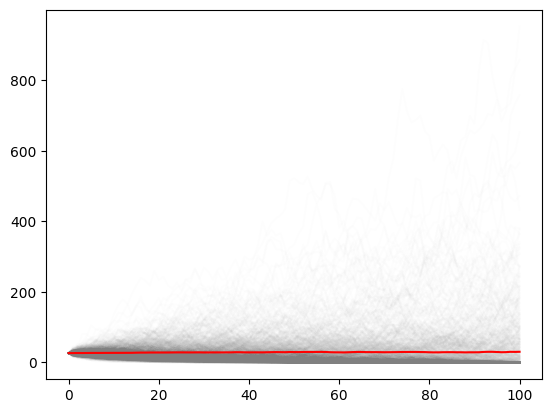

In [97]:
plt.plot(val,alpha=0.01,color="grey")
plt.plot(np.mean(val,axis=1),color="red")
plt.show()

In [98]:
X = val
Pi = val-eta1*S

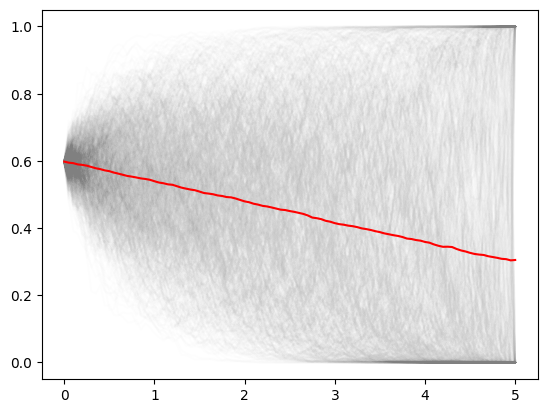

In [99]:
plt.plot(t,eta1,alpha=.01,color="grey")
plt.plot(t,np.mean(eta1,axis=1),color="red")
plt.show()

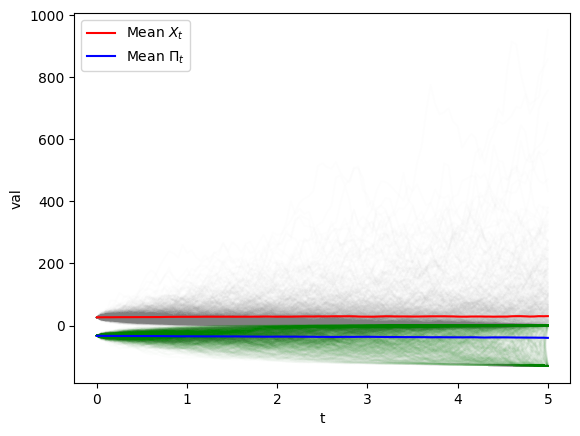

In [100]:
plt.plot(t,X,alpha=0.01,color="grey")
plt.plot(t,np.mean(X,axis=1),color="red",label=fr"Mean $X_t$")

plt.plot(t,Pi,alpha=0.01,color="green")
plt.plot(t,np.mean(Pi,axis=1),color="blue",label=fr"Mean $\Pi_t$")

plt.xlabel("t")
plt.ylabel("val")
plt.legend()
plt.show()


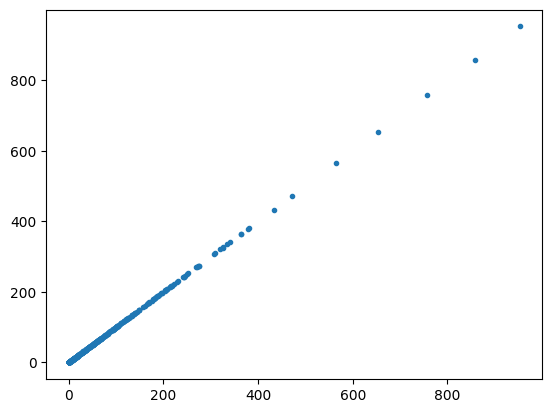

In [101]:
plt.plot(X[-1,:],np.maximum(S[-1,:]-K,0),'.')
plt.show()

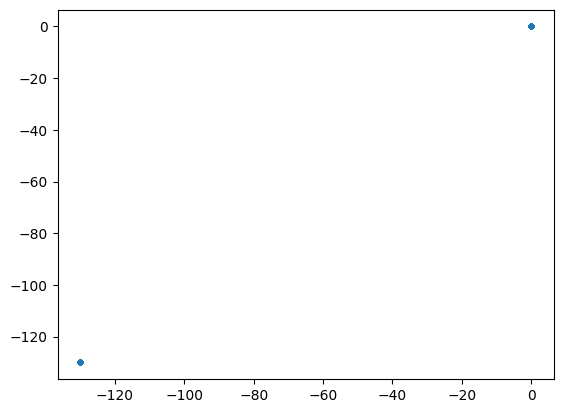

In [102]:
plt.plot(Pi[-1,:],-K*(S[-1,:]>K),'.')
plt.show()
